In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import ttest_rel, pearsonr, ttest_ind
from scipy.spatial.distance import euclidean, cosine,pdist, squareform
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr

In [2]:
vision_pp = np.load('data/evals/perspective_taking/features/perspective/vision_tower_features.npy')
multimodal_pp = np.load('data/evals/perspective_taking/features/perspective/multimodal_projector_features.npy')
language_pp = np.load('data/evals/perspective_taking/features/perspective/language_model_features.npy')
vision_pp.shape, multimodal_pp.shape, language_pp.shape

((24, 577, 1024), (24, 576, 5120), (24, 645, 5120))

In [3]:
vision_base = np.load('data/evals/perspective_taking/features/base/vision_tower_features.npy')
multimodal_base = np.load('data/evals/perspective_taking/features/base/multimodal_projector_features.npy')
language_base = np.load('data/evals/perspective_taking/features/base/language_model_features.npy')
vision_base.shape, multimodal_base.shape, language_base.shape

((24, 577, 1024), (24, 576, 5120), (24, 645, 5120))

###

For preliminary analyses we'll start by averaging the middle (n_token) dimension to get one vector representing each image input

In [4]:
vision_pp_mean = np.mean(vision_pp, axis=1)
multimodal_pp_mean = np.mean(multimodal_pp, axis=1)
language_pp_mean = np.mean(language_pp, axis=1)
vision_base_mean = np.mean(vision_base, axis=1)
multimodal_base_mean = np.mean(multimodal_base, axis=1)
language_base_mean = np.mean(language_base, axis=1)
vision_pp_mean.shape, multimodal_pp_mean.shape, language_pp_mean.shape, vision_base_mean.shape, multimodal_base_mean.shape, language_base_mean.shape

((24, 1024), (24, 5120), (24, 5120), (24, 1024), (24, 5120), (24, 5120))

In [5]:
angles = [0, 45, 60, 90, 120, 135, 180, 225, 240, 270, 300, 315] * 2
# egocentric cube directions (where in image space the cube is located)
left_ans_direction = [0] * 3 + [2] + [1] * 5 + [2] + [0] * 2  # 0 for left, 1 for right, 2 for perpendicular
right_ans_direction = [1] * 3 + [2] + [0] * 5 + [2] + [1] * 2  # 0 for left, 1 for right, 2 for perpendicular
alignment = [0, 0, 0, 2, 1, 1, 1, 1, 1, 2, 0, 0] * 2  # 0 for aligned angle, 1 for unaligned, 2 for perpendicular
cube_direction = left_ans_direction + right_ans_direction  # 0 for left, 1 for right

import pandas as pd
design_df = pd.DataFrame({
    'angle': angles,
    'cube_direction': cube_direction, # 0 for left, 1 for right
    'alignment': alignment
})

print("Design DataFrame Head:")
print(design_df.head())
print("\nDesign DataFrame Tail:")
print(design_df.tail())

Design DataFrame Head:
   angle  cube_direction  alignment
0      0               0          0
1     45               0          0
2     60               0          0
3     90               2          2
4    120               1          1

Design DataFrame Tail:
    angle  cube_direction  alignment
19    225               0          1
20    240               0          1
21    270               2          2
22    300               1          0
23    315               1          0


In [6]:
scaler = StandardScaler()

multimodal_pp_scaled = scaler.fit_transform(multimodal_pp_mean)
multimodal_base_scaled = scaler.fit_transform(multimodal_base_mean)
language_pp_scaled = scaler.fit_transform(language_pp_mean)
language_base_scaled = scaler.fit_transform(language_base_mean)

## Feature selectivity
Find neurons that are correlated with aligned/unaligned (on/off)

In [7]:
perpendicular_indices = np.where(np.array(alignment) == 2)[0]

# remove perpendicular indices from design_df and scaled matrices
design_df_filtered = design_df.drop(perpendicular_indices)
multimodal_pp_scaled_filtered = np.delete(multimodal_pp_scaled, perpendicular_indices, axis=0)
multimodal_base_scaled_filtered = np.delete(multimodal_base_scaled, perpendicular_indices, axis=0)
language_pp_scaled_filtered = np.delete(language_pp_scaled, perpendicular_indices, axis=0)
language_base_scaled_filtered = np.delete(language_base_scaled, perpendicular_indices, axis=0)

# now sigmoid
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

multimodal_pp_sigmoid_filtered = sigmoid(multimodal_pp_scaled_filtered)
multimodal_base_sigmoid_filtered = sigmoid(multimodal_base_scaled_filtered)
language_pp_sigmoid_filtered = sigmoid(language_pp_scaled_filtered)
language_base_sigmoid_filtered = sigmoid(language_base_scaled_filtered)

# we'll keep the original matrices in this analysis as well
multimodal_pp_mean_filtered = np.delete(multimodal_pp_mean, perpendicular_indices, axis=0)
multimodal_base_mean_filtered = np.delete(multimodal_base_mean, perpendicular_indices, axis=0)
language_pp_mean_filtered = np.delete(language_pp_mean, perpendicular_indices, axis=0)
language_base_mean_filtered = np.delete(language_base_mean, perpendicular_indices, axis=0)

# reset indices of design_df_filtered and scaled matrices
design_df_filtered.reset_index(drop=True, inplace=True)

multimodal_pp_scaled_filtered.shape, multimodal_base_scaled_filtered.shape, language_pp_scaled_filtered.shape, language_base_scaled_filtered.shape

((20, 5120), (20, 5120), (20, 5120), (20, 5120))

In [8]:
# Update the scaled_activations dictionary with filtered data
scaled_activations_filtered = {
    'multimodal_projector_base': multimodal_base_scaled_filtered,
    'multimodal_projector_pp': multimodal_pp_scaled_filtered,
    'language_model_base': language_base_scaled_filtered,
    'language_model_pp': language_pp_scaled_filtered,
}

sigmoid_activations_filtered = {
    'multimodal_projector_base': multimodal_base_sigmoid_filtered,
    'multimodal_projector_pp': multimodal_pp_sigmoid_filtered,
    'language_model_base': language_base_sigmoid_filtered,
    'language_model_pp': language_pp_sigmoid_filtered,
}

activations_filtered = {
    'multimodal_projector_base': multimodal_base_mean_filtered,
    'multimodal_projector_pp': multimodal_pp_mean_filtered,
    'language_model_base': language_base_mean_filtered,
    'language_model_pp': language_pp_mean_filtered,
}

print("\nFiltered Design DataFrame Head:")
print(design_df_filtered.head())
print("\nFiltered Scaled Activations Shapes:")
for key, value in scaled_activations_filtered.items():
    print(f"{key}: {value.shape}")


Filtered Design DataFrame Head:
   angle  cube_direction  alignment
0      0               0          0
1     45               0          0
2     60               0          0
3    120               1          1
4    135               1          1

Filtered Scaled Activations Shapes:
multimodal_projector_base: (20, 5120)
multimodal_projector_pp: (20, 5120)
language_model_base: (20, 5120)
language_model_pp: (20, 5120)


In [9]:
selection = 'scaled' # Choose 'scaled' or 'sigmoid' for ROI selection

if selection == 'scaled':
    activation_selection = scaled_activations_filtered  # Use scaled activations for ROI selection
elif selection == 'sigmoid':
    activation_selection = sigmoid_activations_filtered
elif selection == 'mean':
    activation_selection = activations_filtered

roi_neurons_top100 = {}
num_top_neurons = 100

roi_neurons = {}
p_value_threshold = 0.05 # Significance level for t-test

## Map ROI activity over all angles
For each image, visualize the average (with std bars) activity of the group of neurons (ROI)

In [10]:
num_neurons = {}

In [16]:
import matplotlib.cm as cm

print("\n--- Defining ROIs: Neurons active in Unaligned > Aligned ---")
unalign_neur = {}

for layer_name, activations_matrix in activation_selection.items():
    # Get indices for unaligned and aligned conditions in the filtered data
    unaligned_indices = design_df_filtered[design_df_filtered['alignment'] == 1].index
    aligned_indices = design_df_filtered[design_df_filtered['alignment'] == 0].index

    if len(unaligned_indices) == 0 or len(aligned_indices) == 0:
        print(f"Skipping ROI for {layer_name}: Not enough unaligned or aligned samples after filtering.")
        roi_neurons[layer_name] = []
        continue

    selected_roi_indices = []
    neuron_p_values = []
    for neuron_idx in range(activations_matrix.shape[1]):
        neuron_activity_unaligned = activations_matrix[unaligned_indices, neuron_idx]
        neuron_activity_aligned = activations_matrix[aligned_indices, neuron_idx]

        # Perform independent samples t-test
        # We use equal_var=False for Welch's t-test, which is robust to unequal variances
        # alternative='greater' tests if the mean of unaligned is greater than aligned
        t_stat, p_value = ttest_ind(
            neuron_activity_unaligned,
            neuron_activity_aligned,
            equal_var=False,
            alternative='greater' # Test if unaligned mean > aligned mean
        )

        # Select neuron if p-value is below threshold (and t_stat is positive, which 'greater' ensures)
        if p_value < p_value_threshold:
            selected_roi_indices.append(neuron_idx)
            neuron_p_values.append((p_value, neuron_idx))

    roi_neurons[layer_name] = np.array(selected_roi_indices)
    print(f"ROI for {layer_name}: Found {len(selected_roi_indices)} neurons active in Unaligned > Aligned (p < {p_value_threshold})")

    unalign_neur[layer_name] = len(selected_roi_indices)

    # Sort by p-value (ascending) and get the top N neurons
    neuron_p_values.sort(key=lambda x: x[0]) # Sort by p-value
    top_neurons = [idx for p_val, idx in neuron_p_values[:num_top_neurons]]

    roi_neurons_top100[layer_name] = np.array(top_neurons)
    print(f"ROI for {layer_name}: Selected {len(top_neurons)} top neurons.")

num_neurons['unalign_align'] = unalign_neur



--- Defining ROIs: Neurons active in Unaligned > Aligned ---
ROI for multimodal_projector_base: Found 1144 neurons active in Unaligned > Aligned (p < 0.05)
ROI for multimodal_projector_base: Selected 100 top neurons.


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1135: RuntimeWarning: overflow encountered in divide
  rel_diff = xp.max(xp.abs(a_zero_mean), axis=axis,


ROI for multimodal_projector_pp: Found 1317 neurons active in Unaligned > Aligned (p < 0.05)
ROI for multimodal_projector_pp: Selected 100 top neurons.
ROI for language_model_base: Found 931 neurons active in Unaligned > Aligned (p < 0.05)
ROI for language_model_base: Selected 100 top neurons.
ROI for language_model_pp: Found 977 neurons active in Unaligned > Aligned (p < 0.05)
ROI for language_model_pp: Selected 100 top neurons.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Font scaling (global rcParams) ---
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 17
plt.rcParams['xtick.labelsize'] = 15
plt.rcParams['ytick.labelsize'] = 15
plt.rcParams['legend.fontsize'] = 18
plt.rcParams['legend.title_fontsize'] = 20

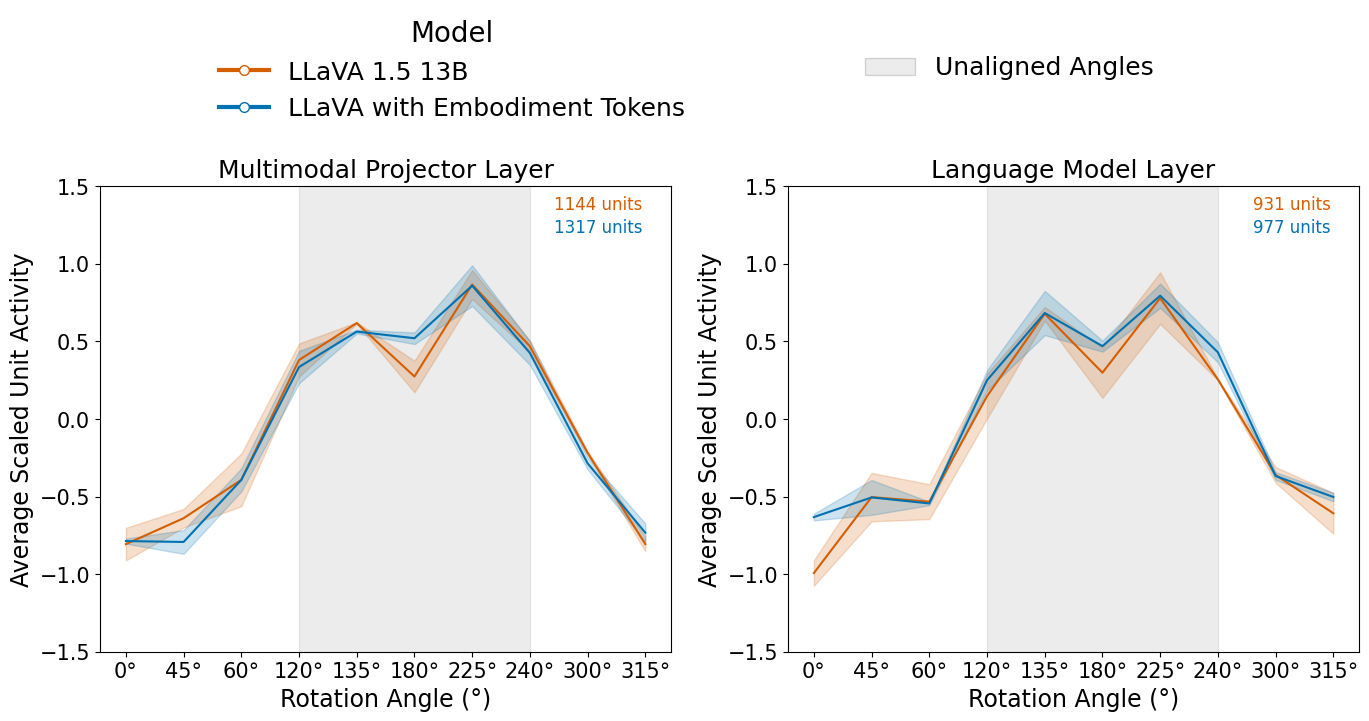

In [15]:
from matplotlib import patches as mpatches

model_colors = {
    "LLaVA 1.5 13B": "#D55E00",  # orange
    "LLaVA with Embodiment Tokens": "#0072B2"  # blue
}

# Define mapping of layers to labels for plotting
layer_groups = {
    'multimodal_projector': ['multimodal_projector_base', 'multimodal_projector_pp'],
    'language_model': ['language_model_base', 'language_model_pp']
}

layer_titles = {
    'multimodal_projector': 'Multimodal Projector Layer',
    'language_model': 'Language Model Layer'
}

plt.figure(figsize=(14, 6))
fig = plt.gcf()

for i, (layer_key, layer_variants) in enumerate(layer_groups.items()):
    ax = plt.subplot(1, 2, i + 1)

    angle_order = None  # to ensure consistent angle ordering
    for layer_name in layer_variants:
        activations_matrix = activation_selection[layer_name]
        current_roi = roi_neurons[layer_name]
        model_label = "LLaVA 1.5 13B" if "base" in layer_name else "LLaVA with Embodiment Tokens"

        if len(current_roi) == 0:
            print(f"No neurons found in ROI for {layer_name}. Skipping.")
            continue

        roi_activity = activations_matrix[:, current_roi]
        data_for_plot = []

        for img_idx in range(activations_matrix.shape[0]):
            image_name = image_name_mapping[img_idx]
            angle = int(image_name.split('_')[1])
            mean_activity = roi_activity[img_idx, :].mean()

            data_for_plot.append({
                'Angle': angle,
                'Activity': mean_activity,
            })

        plot_df = pd.DataFrame(data_for_plot)

        # Map angles to evenly spaced x-axis
        if angle_order is None:
            angle_order = sorted(plot_df['Angle'].unique())
            angle_to_index = {angle: i for i, angle in enumerate(angle_order)}
            index_to_angle = {i: angle for angle, i in angle_to_index.items()}

        plot_df['AngleIdx'] = plot_df['Angle'].map(angle_to_index)
        summary = plot_df.groupby('AngleIdx')['Activity'].agg(['mean', 'std']).reset_index()

        # Plot line and shaded SD
        ax.plot(summary['AngleIdx'], summary['mean'], color=model_colors[model_label])
        ax.fill_between(
            summary['AngleIdx'],
            summary['mean'] - summary['std'],
            summary['mean'] + summary['std'],
            color=model_colors[model_label],
            alpha=0.2
        )

        # Add text annotation for number of selective units
        n_units = len(current_roi)
        ax.text(0.95, 0.95 if "base" in layer_name else 0.90,
                f"{n_units} units",
                color=model_colors[model_label],
                fontsize=12,
                transform=ax.transAxes,
                ha='right')

    # Shade unaligned region
    shade_min, shade_max = 120, 240
    x_vals = pd.Series(angle_order)
    shade_start = x_vals[x_vals >= shade_min].index[0]
    shade_end = x_vals[x_vals <= shade_max].index[-1]

    ax.axvspan(shade_start, shade_end, color='gray', alpha=0.15, zorder=0)

    # Axis labels
    ax.set_xticks(list(index_to_angle.keys()))
    ax.set_xticklabels([f"{index_to_angle[i]}°" for i in index_to_angle])
    ax.set_xlabel('Rotation Angle (°)')
    ax.set_ylabel('Average Scaled Unit Activity')
    ax.set_title(layer_titles[layer_key])

    ax.set_ylim(-1.5, 1.5)

plt.tight_layout()

# Model legend
model_handles = [
    plt.Line2D([0], [0], color=model_colors["LLaVA 1.5 13B"], linewidth=3, marker='o',
               markerfacecolor='white', markersize=7, label="LLaVA 1.5 13B"),
    plt.Line2D([0], [0], color=model_colors["LLaVA with Embodiment Tokens"], linewidth=3, marker='o',
               markerfacecolor='white', markersize=7, label="LLaVA with Embodiment Tokens")
]

# Angle shading legend
angle_handles = [
    plt.Line2D([], [], color='none', label="", linewidth=0),  # for spacing/visual break,
    mpatches.Patch(facecolor='gray', alpha=0.15, edgecolor='black', label='Unaligned Angles')
]

# Combine and add legends
fig.legend(
    handles=model_handles,
    loc='upper left',
    bbox_to_anchor=(0.15, 1.23),
    ncol=1,
    title="Model",
    frameon=False
)

fig.legend(
    handles=angle_handles,
    loc='upper right',
    bbox_to_anchor=(0.85, 1.23),
    ncol=1,
    title="",
    frameon=False
)

plt.savefig('data/evals/visuals/unaligned_roi_visualization_angles_shaded.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
print("\n--- Defining ROIs: Neurons active in Aligned > Unaligned ---")
align_neur = {}

for layer_name, activations_matrix in activation_selection.items():
    # Get indices for unaligned and aligned conditions in the filtered data
    unaligned_indices = design_df_filtered[design_df_filtered['alignment'] == 1].index
    aligned_indices = design_df_filtered[design_df_filtered['alignment'] == 0].index

    if len(unaligned_indices) == 0 or len(aligned_indices) == 0:
        print(f"Skipping ROI for {layer_name}: Not enough unaligned or aligned samples after filtering.")
        roi_neurons[layer_name] = []
        continue

    selected_roi_indices = []
    neuron_p_values = []
    for neuron_idx in range(activations_matrix.shape[1]):
        neuron_activity_unaligned = activations_matrix[unaligned_indices, neuron_idx]
        neuron_activity_aligned = activations_matrix[aligned_indices, neuron_idx]

        # Perform independent samples t-test
        # We use equal_var=False for Welch's t-test, which is robust to unequal variances
        # alternative='greater' tests if the mean of unaligned is greater than aligned
        t_stat, p_value = ttest_ind(
            neuron_activity_aligned,
            neuron_activity_unaligned,
            equal_var=False,
            alternative='greater' # Test if aligned mean > unaligned mean
        )

        # Select neuron if p-value is below threshold (and t_stat is positive, which 'greater' ensures)
        if p_value < p_value_threshold:
            selected_roi_indices.append(neuron_idx)
            neuron_p_values.append((p_value, neuron_idx))

    roi_neurons[layer_name] = np.array(selected_roi_indices)
    print(f"ROI for {layer_name}: Found {len(selected_roi_indices)} neurons active in Aligned > Unaligned (p < {p_value_threshold})")

    align_neur[layer_name] = len(selected_roi_indices)

    # Sort by p-value (ascending) and get the top N neurons
    neuron_p_values.sort(key=lambda x: x[0]) # Sort by p-value
    top_neurons = [idx for p_val, idx in neuron_p_values[:num_top_neurons]]

    roi_neurons_top100[layer_name] = np.array(top_neurons)
    print(f"ROI for {layer_name}: Selected {len(top_neurons)} top neurons.")

num_neurons['align_unalign'] = align_neur


--- Defining ROIs: Neurons active in Aligned > Unaligned ---
ROI for multimodal_projector_base: Found 1082 neurons active in Aligned > Unaligned (p < 0.05)
ROI for multimodal_projector_base: Selected 100 top neurons.
ROI for multimodal_projector_pp: Found 1309 neurons active in Aligned > Unaligned (p < 0.05)
ROI for multimodal_projector_pp: Selected 100 top neurons.
ROI for language_model_base: Found 947 neurons active in Aligned > Unaligned (p < 0.05)
ROI for language_model_base: Selected 100 top neurons.
ROI for language_model_pp: Found 940 neurons active in Aligned > Unaligned (p < 0.05)
ROI for language_model_pp: Selected 100 top neurons.


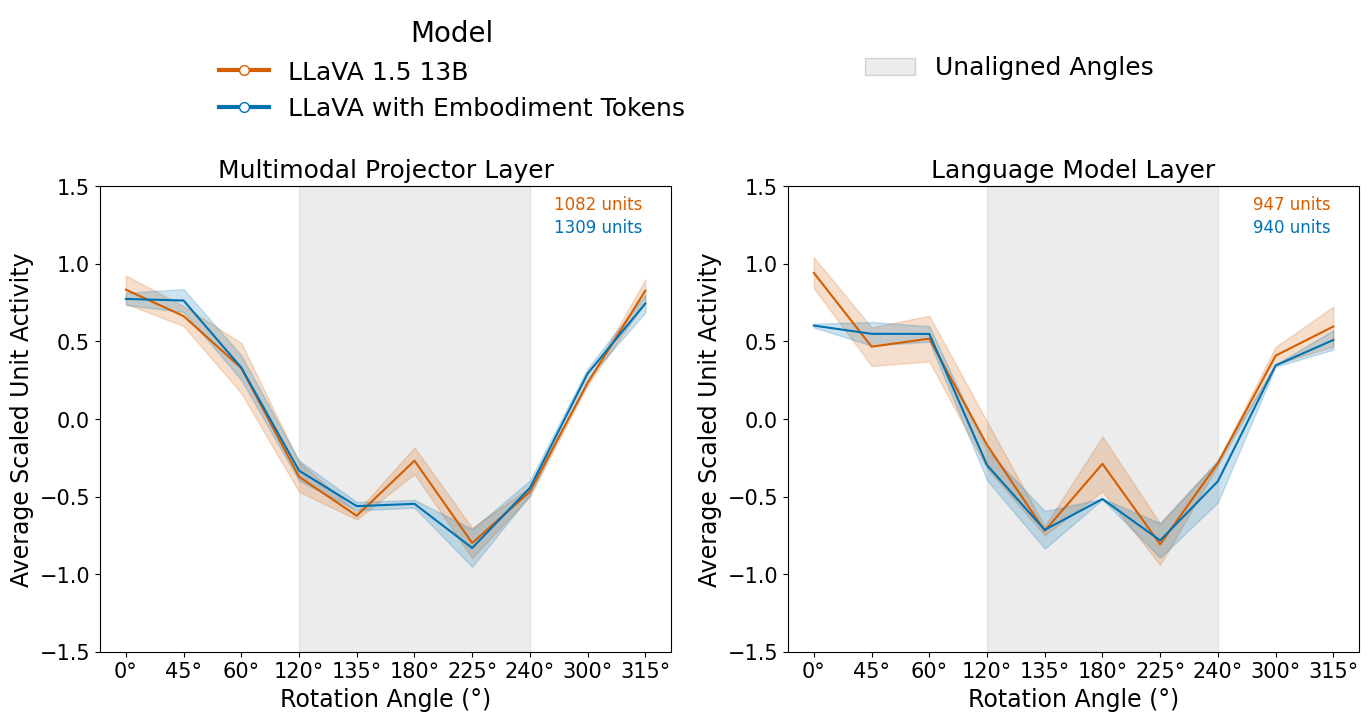

In [18]:
from matplotlib import patches as mpatches

model_colors = {
    "LLaVA 1.5 13B": "#D55E00",  # orange
    "LLaVA with Embodiment Tokens": "#0072B2"  # blue
}

# Define mapping of layers to labels for plotting
layer_groups = {
    'multimodal_projector': ['multimodal_projector_base', 'multimodal_projector_pp'],
    'language_model': ['language_model_base', 'language_model_pp']
}

layer_titles = {
    'multimodal_projector': 'Multimodal Projector Layer',
    'language_model': 'Language Model Layer'
}

plt.figure(figsize=(14, 6))
fig = plt.gcf()

for i, (layer_key, layer_variants) in enumerate(layer_groups.items()):
    ax = plt.subplot(1, 2, i + 1)

    angle_order = None  # to ensure consistent angle ordering
    for layer_name in layer_variants:
        activations_matrix = activation_selection[layer_name]
        current_roi = roi_neurons[layer_name]
        model_label = "LLaVA 1.5 13B" if "base" in layer_name else "LLaVA with Embodiment Tokens"

        if len(current_roi) == 0:
            print(f"No neurons found in ROI for {layer_name}. Skipping.")
            continue

        roi_activity = activations_matrix[:, current_roi]
        data_for_plot = []

        for img_idx in range(activations_matrix.shape[0]):
            image_name = image_name_mapping[img_idx]
            angle = int(image_name.split('_')[1])
            mean_activity = roi_activity[img_idx, :].mean()

            data_for_plot.append({
                'Angle': angle,
                'Activity': mean_activity,
            })

        plot_df = pd.DataFrame(data_for_plot)

        # Map angles to evenly spaced x-axis
        if angle_order is None:
            angle_order = sorted(plot_df['Angle'].unique())
            angle_to_index = {angle: i for i, angle in enumerate(angle_order)}
            index_to_angle = {i: angle for angle, i in angle_to_index.items()}

        plot_df['AngleIdx'] = plot_df['Angle'].map(angle_to_index)
        summary = plot_df.groupby('AngleIdx')['Activity'].agg(['mean', 'std']).reset_index()

        # Plot line and shaded SD
        ax.plot(summary['AngleIdx'], summary['mean'], color=model_colors[model_label])
        ax.fill_between(
            summary['AngleIdx'],
            summary['mean'] - summary['std'],
            summary['mean'] + summary['std'],
            color=model_colors[model_label],
            alpha=0.2
        )

        # Add text annotation for number of selective units
        n_units = len(current_roi)
        ax.text(0.95, 0.95 if "base" in layer_name else 0.90,
                f"{n_units} units",
                color=model_colors[model_label],
                fontsize=12,
                transform=ax.transAxes,
                ha='right')

    # Shade unaligned region
    shade_min, shade_max = 120, 240
    x_vals = pd.Series(angle_order)
    shade_start = x_vals[x_vals >= shade_min].index[0]
    shade_end = x_vals[x_vals <= shade_max].index[-1]

    ax.axvspan(shade_start, shade_end, color='gray', alpha=0.15, zorder=0)

    # Axis labels
    ax.set_xticks(list(index_to_angle.keys()))
    ax.set_xticklabels([f"{index_to_angle[i]}°" for i in index_to_angle])
    ax.set_xlabel('Rotation Angle (°)')
    ax.set_ylabel('Average Scaled Unit Activity')
    ax.set_title(layer_titles[layer_key])

    ax.set_ylim(-1.5, 1.5)

plt.tight_layout()

# Model legend
model_handles = [
    plt.Line2D([0], [0], color=model_colors["LLaVA 1.5 13B"], linewidth=3, marker='o',
               markerfacecolor='white', markersize=7, label="LLaVA 1.5 13B"),
    plt.Line2D([0], [0], color=model_colors["LLaVA with Embodiment Tokens"], linewidth=3, marker='o',
               markerfacecolor='white', markersize=7, label="LLaVA with Embodiment Tokens")
]

# Angle shading legend
angle_handles = [
    plt.Line2D([], [], color='none', label="", linewidth=0),  # for spacing/visual break,
    mpatches.Patch(facecolor='gray', alpha=0.15, edgecolor='black', label='Unaligned Angles')
]

# Combine and add legends
fig.legend(
    handles=model_handles,
    loc='upper left',
    bbox_to_anchor=(0.15, 1.23),
    ncol=1,
    title="Model",
    frameon=False
)

fig.legend(
    handles=angle_handles,
    loc='upper right',
    bbox_to_anchor=(0.85, 1.23),
    ncol=1,
    title="",
    frameon=False
)

plt.savefig('data/evals/visuals/aligned_roi_visualization_angles_shaded.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# ==============================================================
# Permutation Null Test for Feature-Selective Unit Counts
# ==============================================================
# Reviewer concern: at uncorrected p<threshold, ~threshold*100%
# of null units pass by chance. Label-permutation null using the
# SAME Welch t-test selection function as cells 35 / 39.
# ==============================================================
import time
import os

# --- Parameters (adjust or pass as script args) ---
N_PERMS     = 10000    # permutation iterations
SEED        = 0       # reproducibility
P_THRESHOLD = 0.05    # α (notebook's p_value_threshold=0.01; adjust to match)

print(f'RNG seed: {SEED}')
print(f'Params: N_PERMS={N_PERMS}, SEED={SEED}, P_THRESHOLD={P_THRESHOLD}')
print(f'(Notebook p_value_threshold={p_value_threshold}; '
      f'set P_THRESHOLD={p_value_threshold} to match existing counts.)')

# --- True condition labels: 0=aligned, 1=unaligned (perp. already removed) ---
true_labels = design_df_filtered['alignment'].values.copy().astype(int)
n_al  = int((true_labels == 0).sum())
n_un  = int((true_labels == 1).sum())
print(f'\nLabel vector: {n_al} aligned + {n_un} unaligned = {len(true_labels)} stimuli')
print('Both models share this label vector → paired difference test is valid.')

# Contrasts, matching cells 35 and 39 exactly:
#   'unalign_align': ttest_ind(unaligned, aligned, alternative='greater')  [cell 35]
#   'align_unalign': ttest_ind(unaligned, aligned, alternative='less')     [cell 39, equiv.]
CONTRASTS = {
    'unalign_align': 'greater',
    'align_unalign': 'less',
}

LAYER_PAIRS = [
    ('multimodal_projector_pp', 'multimodal_projector_base', 'multimodal_projector'),
    ('language_model_pp',       'language_model_base',       'language_model'),
]

# --- Selection function: vectorized equivalent of per-neuron loop in cells 35/39 ---
def count_selective_units(acts, cond_labels, p_thr, alternative):
    """
    Count units passing Welch t-test between unaligned (label=1) and aligned (label=0).
    Vectorized across neurons (axis=0) — identical result to the per-neuron loop.
    alternative='greater': unaligned > aligned  (cell 35)
    alternative='less':    aligned > unaligned  (cell 39)
    """
    grp_un = acts[cond_labels == 1]   # shape: (n_unaligned, n_units)
    grp_al = acts[cond_labels == 0]   # shape: (n_aligned,   n_units)
    _, p_vals = ttest_ind(grp_un, grp_al, axis=0, equal_var=False, alternative=alternative)
    return int(np.sum(p_vals < p_thr))

# --- Observed counts with real labels ---
observed_counts = {}
for lk, acts in activation_selection.items():
    observed_counts[lk] = {
        c: count_selective_units(acts, true_labels, P_THRESHOLD, alt)
        for c, alt in CONTRASTS.items()
    }

print(f'\nObserved counts (P_THRESHOLD={P_THRESHOLD}):')
for lk, counts in observed_counts.items():
    for c, n in counts.items():
        print(f'  {lk} | {c}: {n}')

# --- Cross-check: function must reproduce unalign_neur / align_neur at notebook's threshold ---
print(f'\nCross-check vs unalign_neur/align_neur at notebook p_value_threshold={p_value_threshold}:')
all_ok = True
for lk, acts in activation_selection.items():
    obs_u = count_selective_units(acts, true_labels, p_value_threshold, 'greater')
    obs_a = count_selective_units(acts, true_labels, p_value_threshold, 'less')
    exp_u = unalign_neur.get(lk, '?')
    exp_a = align_neur.get(lk, '?')
    ok_u = obs_u == exp_u
    ok_a = obs_a == exp_a
    all_ok = all_ok and ok_u and ok_a
    tag_u = 'OK' if ok_u else f'MISMATCH: got {obs_u}, stored {exp_u}'
    tag_a = 'OK' if ok_a else f'MISMATCH: got {obs_a}, stored {exp_a}'
    print(f'  {lk}: unalign_align={obs_u} [{tag_u}], align_unalign={obs_a} [{tag_a}]')
print('Selection function verified.' if all_ok else 'WARNING: mismatch — check activation_selection and p_value_threshold.')

# --- Smoke test: 20 permutations ---
N_SMOKE  = 20
rng_s    = np.random.default_rng(SEED)
smoke_c  = {lk: {c: [] for c in CONTRASTS} for lk in activation_selection}
smoke_d  = {ln: {c: [] for c in CONTRASTS} for _, _, ln in LAYER_PAIRS}

t0 = time.time()
for _ in range(N_SMOKE):
    sh = rng_s.permutation(true_labels)
    for c, alt in CONTRASTS.items():
        for pp_key, base_key, ln in LAYER_PAIRS:
            c_pp   = count_selective_units(activation_selection[pp_key],   sh, P_THRESHOLD, alt)
            c_base = count_selective_units(activation_selection[base_key], sh, P_THRESHOLD, alt)
            smoke_c[pp_key][c].append(c_pp)
            smoke_c[base_key][c].append(c_base)
            smoke_d[ln][c].append(c_pp - c_base)
t_smoke   = time.time() - t0
t_per     = t_smoke / N_SMOKE

print(f'\nSmoke test ({N_SMOKE} perms): {t_smoke:.2f}s  ({t_per:.3f}s/perm)')
print(f'Estimated time for {N_PERMS} perms: {t_per * N_PERMS / 60:.1f} min')

print('\nSmoke test output format (per-model):')
for lk in activation_selection:
    for c in CONTRASTS:
        obs  = observed_counts[lk][c]
        null = np.array(smoke_c[lk][c])
        ep   = (1 + np.sum(null >= obs)) / (N_SMOKE + 1)
        print(f'  {lk} | {c}: obs={obs}, null_mean={null.mean():.1f}, '
              f'null=[{null.min()}–{null.max()}], p_emp={ep:.3f}')

print('\nSmoke test output format (pp − base difference):')
for _, _, ln in LAYER_PAIRS:
    for c in CONTRASTS:
        obs_d = (observed_counts[f'{ln}_pp'][c] - observed_counts[f'{ln}_base'][c])
        null  = np.array(smoke_d[ln][c])
        ep    = (1 + np.sum(null >= obs_d)) / (N_SMOKE + 1)
        print(f'  {ln} | {c}: obs_diff={obs_d:+d}, null_mean={null.mean():.1f}, '
              f'null=[{null.min()}–{null.max()}], p_emp={ep:.3f}')


RNG seed: 0
Params: N_PERMS=10000, SEED=0, P_THRESHOLD=0.05
(Notebook p_value_threshold=0.05; set P_THRESHOLD=0.05 to match existing counts.)

Label vector: 10 aligned + 10 unaligned = 20 stimuli
Both models share this label vector → paired difference test is valid.

Observed counts (P_THRESHOLD=0.05):
  multimodal_projector_base | unalign_align: 1144
  multimodal_projector_base | align_unalign: 1082
  multimodal_projector_pp | unalign_align: 1317
  multimodal_projector_pp | align_unalign: 1309
  language_model_base | unalign_align: 931
  language_model_base | align_unalign: 946
  language_model_pp | unalign_align: 977
  language_model_pp | align_unalign: 940

Cross-check vs unalign_neur/align_neur at notebook p_value_threshold=0.05:
  multimodal_projector_base: unalign_align=1144 [OK], align_unalign=1082 [OK]
  multimodal_projector_pp: unalign_align=1317 [OK], align_unalign=1309 [OK]
  language_model_base: unalign_align=931 [OK], align_unalign=946 [MISMATCH: got 946, stored 947]
  lan

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1135: RuntimeWarning: overflow encountered in divide
  rel_diff = xp.max(xp.abs(a_zero_mean), axis=axis,



Smoke test (20 perms): 0.79s  (0.040s/perm)
Estimated time for 10000 perms: 6.6 min

Smoke test output format (per-model):
  multimodal_projector_base | unalign_align: obs=1144, null_mean=279.6, null=[49–611], p_emp=0.048
  multimodal_projector_base | align_unalign: obs=1082, null_mean=287.2, null=[32–610], p_emp=0.048
  multimodal_projector_pp | unalign_align: obs=1317, null_mean=288.9, null=[44–715], p_emp=0.048
  multimodal_projector_pp | align_unalign: obs=1309, null_mean=293.4, null=[34–698], p_emp=0.048
  language_model_base | unalign_align: obs=931, null_mean=282.8, null=[45–667], p_emp=0.048
  language_model_base | align_unalign: obs=946, null_mean=282.4, null=[55–662], p_emp=0.048
  language_model_pp | unalign_align: obs=977, null_mean=271.2, null=[48–616], p_emp=0.048
  language_model_pp | align_unalign: obs=940, null_mean=268.6, null=[62–563], p_emp=0.048

Smoke test output format (pp − base difference):
  multimodal_projector | unalign_align: obs_diff=+173, null_mean=9.2, 

In [23]:
# ==============================================================
# Full Permutation Test: N_PERMS iterations
# ==============================================================

rng = np.random.default_rng(SEED)
print(f'Running {N_PERMS} permutations (seed={SEED}, P_THRESHOLD={P_THRESHOLD})...')

null_counts = {lk: {c: np.zeros(N_PERMS, dtype=int) for c in CONTRASTS}
               for lk in activation_selection}
null_diffs  = {ln: {c: np.zeros(N_PERMS, dtype=int) for c in CONTRASTS}
               for _, _, ln in LAYER_PAIRS}

t0 = time.time()
for i in range(N_PERMS):
    sh = rng.permutation(true_labels)
    for c, alt in CONTRASTS.items():
        for pp_key, base_key, ln in LAYER_PAIRS:
            c_pp   = count_selective_units(activation_selection[pp_key],   sh, P_THRESHOLD, alt)
            c_base = count_selective_units(activation_selection[base_key], sh, P_THRESHOLD, alt)
            null_counts[pp_key][c][i]   = c_pp
            null_counts[base_key][c][i] = c_base
            null_diffs[ln][c][i]        = c_pp - c_base

elapsed = time.time() - t0
print(f'Done in {elapsed:.1f}s  ({elapsed / N_PERMS:.3f}s/perm)')

# --- Save null distributions ---
save_dir = 'data/evals/permutation_null'
os.makedirs(save_dir, exist_ok=True)

save_kwargs = {}
for lk in null_counts:
    for c in CONTRASTS:
        save_kwargs[f'counts__{lk}__{c}'] = null_counts[lk][c]
for ln in null_diffs:
    for c in CONTRASTS:
        save_kwargs[f'diff__{ln}__{c}'] = null_diffs[ln][c]
save_kwargs['true_labels'] = true_labels
save_kwargs['seed']        = np.array(SEED)
save_kwargs['n_perms']     = np.array(N_PERMS)
save_kwargs['p_threshold'] = np.array(P_THRESHOLD)

np.savez(os.path.join(save_dir, 'null_distributions.npz'), **save_kwargs)
print(f'Null distributions saved to {save_dir}/null_distributions.npz')

# --- Empirical p-value: (1 + #{null >= obs}) / (N_PERMS + 1) ---
def empirical_p(obs, null):
    return (1 + int(np.sum(null >= obs))) / (len(null) + 1)

# --- Build summary table ---
rows = []

for lk in activation_selection:
    for c in CONTRASTS:
        obs  = observed_counts[lk][c]
        null = null_counts[lk][c]
        rows.append({
            'type':         'per_model',
            'model_layer':  lk,
            'contrast':     c,
            'observed':     obs,
            'null_mean':    round(float(null.mean()), 2),
            'ci_low_2.5':   round(float(np.percentile(null, 2.5)),  2),
            'ci_high_97.5': round(float(np.percentile(null, 97.5)), 2),
            'p_empirical':  round(empirical_p(obs, null), 4),
        })

for _, _, ln in LAYER_PAIRS:
    for c in CONTRASTS:
        obs_d = (observed_counts[f'{ln}_pp'][c] - observed_counts[f'{ln}_base'][c])
        null  = null_diffs[ln][c]
        rows.append({
            'type':         'difference_pp_minus_base',
            'model_layer':  ln,
            'contrast':     c,
            'observed':     obs_d,
            'null_mean':    round(float(null.mean()), 2),
            'ci_low_2.5':   round(float(np.percentile(null, 2.5)),  2),
            'ci_high_97.5': round(float(np.percentile(null, 97.5)), 2),
            'p_empirical':  round(empirical_p(obs_d, null), 4),
        })

perm_summary_df = pd.DataFrame(rows)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)
print(f'\nPermutation test summary (N_PERMS={N_PERMS}, seed={SEED}, P_THRESHOLD={P_THRESHOLD}):')
print(perm_summary_df.to_string(index=False))

perm_summary_df.to_csv(os.path.join(save_dir, 'permutation_summary.csv'), index=False)
print(f'\nSummary table saved to {save_dir}/permutation_summary.csv')


Running 10000 permutations (seed=0, P_THRESHOLD=0.05)...
Done in 349.9s  (0.035s/perm)
Null distributions saved to data/evals/permutation_null/null_distributions.npz

Permutation test summary (N_PERMS=10000, seed=0, P_THRESHOLD=0.05):
                    type               model_layer      contrast  observed  null_mean  ci_low_2.5  ci_high_97.5  p_empirical
               per_model multimodal_projector_base unalign_align      1144     258.07       29.00        889.07       0.0051
               per_model multimodal_projector_base align_unalign      1082     258.13       29.00        891.02       0.0082
               per_model   multimodal_projector_pp unalign_align      1317     257.34       27.00        832.05       0.0001
               per_model   multimodal_projector_pp align_unalign      1309     257.51       28.00        837.02       0.0001
               per_model       language_model_base unalign_align       931     257.43       34.00        862.02       0.0194
               

Saved to data/evals/visuals/permutation_null_histograms.png


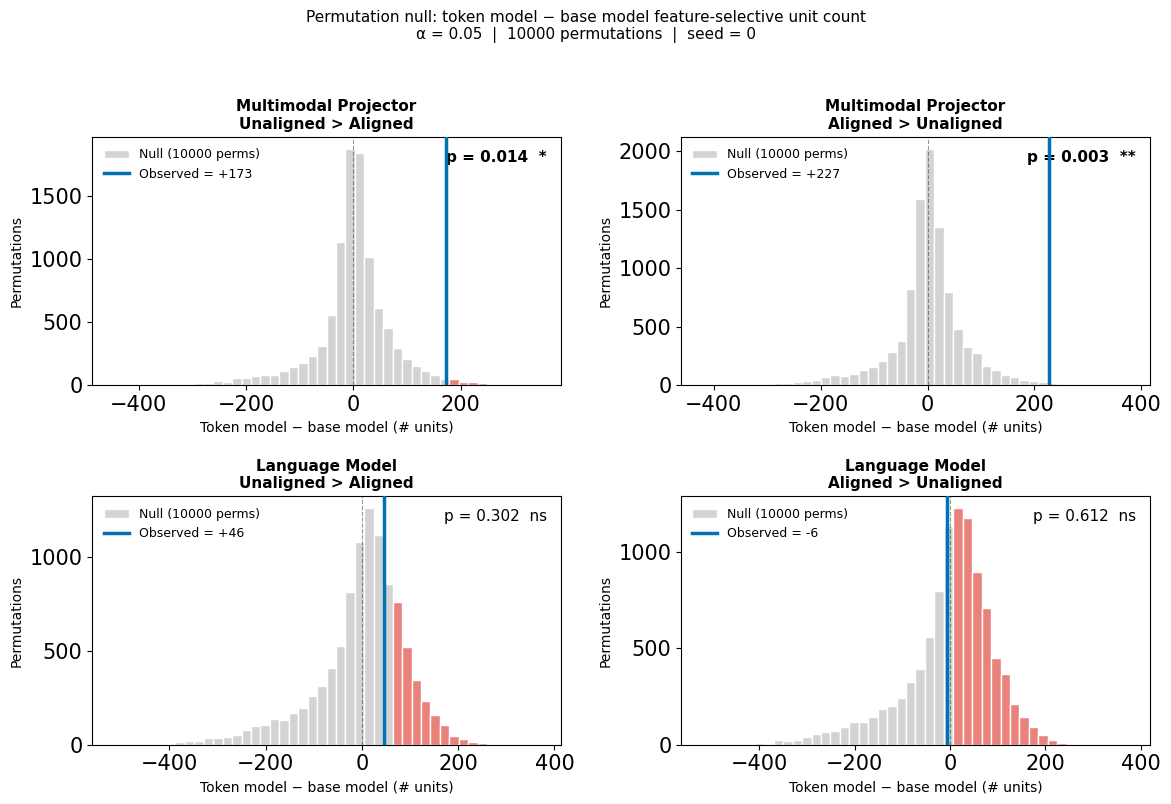

In [24]:
# ==============================================================
# Supplementary Figure: Permutation Null Distributions
# One panel per layer x contrast — histogram of null (pp-base)
# with observed difference marked.
# ==============================================================

panel_order = [
    ('multimodal_projector', 'unalign_align', 'Multimodal Projector\nUnaligned > Aligned'),
    ('multimodal_projector', 'align_unalign', 'Multimodal Projector\nAligned > Unaligned'),
    ('language_model',       'unalign_align', 'Language Model\nUnaligned > Aligned'),
    ('language_model',       'align_unalign', 'Language Model\nAligned > Unaligned'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (layer, contrast, title) in zip(axes.flat, panel_order):
    null     = null_diffs[layer][contrast]
    obs_diff = (observed_counts[f'{layer}_pp'][contrast]
                - observed_counts[f'{layer}_base'][contrast])
    p_emp    = (1 + int(np.sum(null >= obs_diff))) / (N_PERMS + 1)
    sig      = '**' if p_emp < 0.01 else ('*' if p_emp < 0.05 else 'ns')

    # x range covers both null and observed value
    span   = max(null.max() - null.min(), abs(obs_diff), 1)
    margin = span * 0.12
    x_lo   = min(null.min(), obs_diff) - margin
    x_hi   = max(null.max(), obs_diff) + margin

    # Main null histogram
    counts, bin_edges, patches = ax.hist(
        null, bins=40, color='lightgray', edgecolor='white',
        zorder=2, label=f'Null ({N_PERMS} perms)'
    )

    # Colour bars in the tail (>= observed) red
    for patch, left in zip(patches, bin_edges[:-1]):
        if left >= obs_diff:
            patch.set_facecolor('#E8827A')

    # Observed difference — vertical line
    ax.axvline(obs_diff, color='#0072B2', linewidth=2.5, zorder=5,
               label=f'Observed = {obs_diff:+d}')

    # Zero reference
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)

    # p-value annotation
    fw = 'bold' if sig != 'ns' else 'normal'
    ax.text(0.97, 0.95, f'p = {p_emp:.3f}  {sig}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=11, fontweight=fw,
            bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85))

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Token model \u2212 base model (# units)', fontsize=10)
    ax.set_ylabel('Permutations', fontsize=10)
    ax.set_xlim(x_lo, x_hi)
    ax.legend(frameon=False, fontsize=9, loc='upper left')

plt.suptitle(
    f'Permutation null: token model \u2212 base model feature-selective unit count\n'
    f'\u03b1 = {P_THRESHOLD}  |  {N_PERMS} permutations  |  seed = {SEED}',
    fontsize=11, y=1.01
)
plt.tight_layout()

save_path = 'data/evals/visuals/permutation_null_histograms.png'
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved to {save_path}')
plt.show()


In [25]:
# ==============================================================
# Threshold Robustness: Observed Counts at Multiple α Levels
# No additional permutations. Shows whether the token-model
# advantage holds across α choices.
# ==============================================================

print('Threshold robustness — observed counts at p<0.05 / 0.01 / 0.001:\n')

thresholds = [0.05, 0.01, 0.001]
rob_rows = []

for p_thr in thresholds:
    for c, alt in CONTRASTS.items():
        row = {'p_threshold': p_thr, 'contrast': c}
        for lk, acts in activation_selection.items():
            row[lk] = count_selective_units(acts, true_labels, p_thr, alt)
        for _, _, ln in LAYER_PAIRS:
            row[f'diff_{ln}_(pp-base)'] = row[f'{ln}_pp'] - row[f'{ln}_base']
        rob_rows.append(row)

rob_df = pd.DataFrame(rob_rows)
print(rob_df.to_string(index=False))

rob_df.to_csv(os.path.join(save_dir, 'threshold_robustness.csv'), index=False)
print(f'\nThreshold robustness saved to {save_dir}/threshold_robustness.csv')


Threshold robustness — observed counts at p<0.05 / 0.01 / 0.001:



/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/scipy/stats/_stats_py.py:1135: RuntimeWarning: overflow encountered in divide
  rel_diff = xp.max(xp.abs(a_zero_mean), axis=axis,


 p_threshold      contrast  multimodal_projector_base  multimodal_projector_pp  language_model_base  language_model_pp  diff_multimodal_projector_(pp-base)  diff_language_model_(pp-base)
       0.050 unalign_align                       1144                     1317                  931                977                                  173                             46
       0.050 align_unalign                       1082                     1309                  946                940                                  227                             -6
       0.010 unalign_align                        695                      873                  500                499                                  178                             -1
       0.010 align_unalign                        609                      834                  492                518                                  225                             26
       0.001 unalign_align                        296            

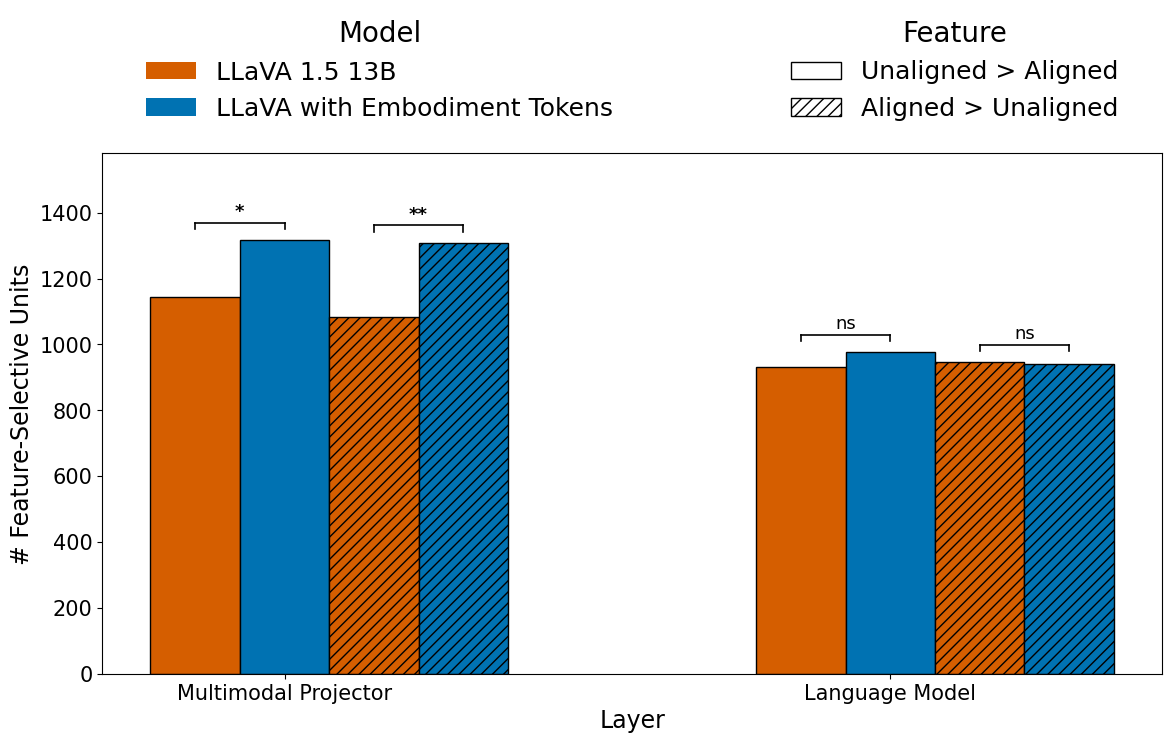

In [26]:
from matplotlib.patches import Patch

keep_features = ["unalign_align", "align_unalign"]

custom_colors_model = {
    "LLaVA 1.5 13B": "#D55E00",
    "LLaVA with Embodiment Tokens": "#0072B2"
}
feature_hatches = {
    "unalign_align": "",
    "align_unalign": "///"
}

layer_order = ["multimodal_projector", "language_model"]
model_order = ["base", "pp"]

try:
    _have_perm = null_counts is not None and null_diffs is not None
except NameError:
    _have_perm = False
    print('WARNING: run the full permutation test cell first for significance labels.')

def _bar_val(layer, feature, model):
    if _have_perm:
        return observed_counts[f'{layer}_{model}'][feature]
    # fallback to num_neurons at notebook p_value_threshold
    _df = df_melted[df_melted['feature'].isin(keep_features)]
    _dg = _df.groupby(['feature','layer','model_type'])['count'].sum().reset_index()
    rows = _dg[(_dg['layer']==layer)&(_dg['feature']==feature)&(_dg['model_type']==model)]
    return int(rows['count'].sum()) if len(rows) else 0

def _sig_label(p):
    if p < 0.01:   return '**'
    elif p < 0.05: return '*'
    else:          return 'ns'

# ---------------------------
# Layout
# ---------------------------
bar_width         = 0.18
feature_grp_width = bar_width * 2
layer_grp_width   = feature_grp_width * 2
x_positions       = np.arange(len(layer_order)) * (layer_grp_width + 0.5)

fig, ax = plt.subplots(figsize=(12, 8))

# ---------------------------
# Draw bars; track (x, height) for bracket placement
# ---------------------------
bar_info = {}  # (layer, feature, model) -> (x_center, height)

for l_idx, layer in enumerate(layer_order):
    for f_idx, feature in enumerate(keep_features):
        for m_idx, model in enumerate(model_order):
            x   = x_positions[l_idx] + f_idx * feature_grp_width + m_idx * bar_width
            val = _bar_val(layer, feature, model)
            color = (custom_colors_model['LLaVA 1.5 13B'] if model == 'base'
                     else custom_colors_model['LLaVA with Embodiment Tokens'])
            ax.bar(x, val, width=bar_width, color=color, edgecolor='black',
                   hatch=feature_hatches[feature])
            bar_info[(layer, feature, model)] = (x, val)

# ---------------------------
# Significance brackets
# ---------------------------
if _have_perm:
    y_max     = max(v for (_, v) in bar_info.values())
    gap       = y_max * 0.04   # space between bar top and bracket
    tick_h    = y_max * 0.015  # vertical cap height

    for l_idx, layer in enumerate(layer_order):
        for f_idx, feature in enumerate(keep_features):
            x_base, v_base = bar_info[(layer, feature, 'base')]
            x_pp,   v_pp   = bar_info[(layer, feature, 'pp')]

            obs_diff = v_pp - v_base
            null     = null_diffs[layer][feature]
            p_emp    = (1 + int(np.sum(null >= obs_diff))) / (N_PERMS + 1)
            label    = _sig_label(p_emp)

            y_brack  = max(v_base, v_pp) + gap
            x_mid    = (x_base + x_pp) / 2

            # Horizontal bar + vertical end ticks
            ax.plot([x_base, x_pp],   [y_brack, y_brack],         'k-', lw=1.2)
            ax.plot([x_base, x_base], [y_brack - tick_h, y_brack],'k-', lw=1.2)
            ax.plot([x_pp,   x_pp  ], [y_brack - tick_h, y_brack],'k-', lw=1.2)

            fw = 'bold' if label != 'ns' else 'normal'
            ax.text(x_mid, y_brack + tick_h * 0.3, label,
                    ha='center', va='bottom', fontsize=13, fontweight=fw)

    ax.set_ylim(0, y_max * 1.20)

# ---------------------------
# Axis formatting
# ---------------------------
ax.set_ylabel('# Feature-Selective Units')
ax.set_xlabel('Layer')

layer_centers = x_positions + layer_grp_width / 2 - bar_width
ax.set_xticks(layer_centers)
ax.set_xticklabels(['Multimodal Projector', 'Language Model'])

# ---------------------------
# Legends
# ---------------------------
model_handles = [
    Patch(facecolor=custom_colors_model['LLaVA 1.5 13B'],
          label='LLaVA 1.5 13B'),
    Patch(facecolor=custom_colors_model['LLaVA with Embodiment Tokens'],
          label='LLaVA with Embodiment Tokens'),
]
feature_handles = [
    Patch(facecolor='white', edgecolor='black', hatch='',    label='Unaligned > Aligned'),
    Patch(facecolor='white', edgecolor='black', hatch='///', label='Aligned > Unaligned'),
]

legend1 = ax.legend(handles=model_handles, title='Model', frameon=False,
                    loc='upper left', bbox_to_anchor=(0.02, 1.3))
ax.add_artist(legend1)
ax.legend(handles=feature_handles, title='Feature', frameon=False,
          loc='upper right', bbox_to_anchor=(0.98, 1.3))

plt.tight_layout()
plt.savefig('data/evals/visuals/neuron_counts_by_feature.png', dpi=300)
plt.show()
